In [1]:
# ============================================================
# W7 CELL 1 — LOAD FEATURE-ENGINEERED DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load the same feature-engineered data used in W6
train_fe = pd.read_csv("../data/train_fe_w6.csv")
test_fe = pd.read_csv("../data/test_fe_w6.csv")

# Restore Date datatype
train_fe["Date"] = pd.to_datetime(train_fe["Date"])
test_fe["Date"] = pd.to_datetime(test_fe["Date"])

print("W7 data loaded successfully.")

print("\nTraining shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nTraining date range:")
print(train_fe["Date"].min(), "to", train_fe["Date"].max())

print("\nTest date range:")
print(test_fe["Date"].min(), "to", test_fe["Date"].max())

W7 data loaded successfully.

Training shape: (15636, 22)
Test shape: (8681, 22)

Training date range:
2015-01-02 00:00:00 to 2019-05-25 00:00:00

Test date range:
2019-05-26 00:00:00 to 2020-06-30 00:00:00


In [2]:
# ============================================================
# W7 CELL 2 — HAZARDOUS-AIR-DAY TARGET
# ============================================================

HAZARDOUS_THRESHOLD = 301

train_fe["Hazardous_Tomorrow"] = (
    train_fe["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

test_fe["Hazardous_Tomorrow"] = (
    test_fe["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

TARGET = "Hazardous_Tomorrow"

print("Hazardous threshold:", HAZARDOUS_THRESHOLD)

print("\nTraining target distribution:")
print(train_fe[TARGET].value_counts().sort_index())

print("\nTest target distribution:")
print(test_fe[TARGET].value_counts().sort_index())

print("\nTarget meaning:")
print("0 = Non-hazardous tomorrow")
print("1 = Hazardous tomorrow")

Hazardous threshold: 301

Training target distribution:
Hazardous_Tomorrow
0    12642
1     2994
Name: count, dtype: int64

Test target distribution:
Hazardous_Tomorrow
0    8082
1     599
Name: count, dtype: int64

Target meaning:
0 = Non-hazardous tomorrow
1 = Hazardous tomorrow


In [3]:
# ============================================================
# W7 CELL 3 — PREPARE FEATURES FOR RANDOM FOREST
# ============================================================

EXCLUDE_COLUMNS = [
    "City",
    "Date",
    "Tomorrow_AQI",
    "Hazardous_Tomorrow",
    "AQI_Bucket",
    "AQI"              # duplicate of AQI_Current
]

RF_FEATURES = [
    col for col in train_fe.columns
    if col not in EXCLUDE_COLUMNS
]

X_train_rf = train_fe[RF_FEATURES].copy()
X_test_rf = test_fe[RF_FEATURES].copy()

y_train_rf = train_fe[TARGET].copy()
y_test_rf = test_fe[TARGET].copy()

print("Random Forest features prepared.")

print("\nNumber of features:", len(RF_FEATURES))
print(RF_FEATURES)

print("\nTraining shape:", X_train_rf.shape)
print("Test shape:", X_test_rf.shape)

print("\nMissing values before imputation:")
print("Training:", X_train_rf.isna().sum().sum())
print("Test:", X_test_rf.isna().sum().sum())

Random Forest features prepared.

Number of features: 17
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month']

Training shape: (15636, 17)
Test shape: (8681, 17)

Missing values before imputation:
Training: 30279
Test: 12006


In [4]:
# ============================================================
# W7 CELL 4 — HANDLE MISSING VALUES
# ============================================================

# Create median imputer
imputer_rf = SimpleImputer(strategy="median")

# Fit ONLY on training data
X_train_rf_imputed = imputer_rf.fit_transform(X_train_rf)

# Apply the training medians to test data
X_test_rf_imputed = imputer_rf.transform(X_test_rf)

print("Random Forest preprocessing completed.")

print("\nTraining shape:", X_train_rf_imputed.shape)
print("Test shape:", X_test_rf_imputed.shape)

print("\nMissing values after imputation:")
print("Training:", np.isnan(X_train_rf_imputed).sum())
print("Test:", np.isnan(X_test_rf_imputed).sum())

Random Forest preprocessing completed.

Training shape: (15636, 17)
Test shape: (8681, 17)

Missing values after imputation:
Training: 0
Test: 0


In [5]:
# ============================================================
# W7 CELL 5 — TRAIN RANDOM FOREST CLASSIFIER
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train Random Forest
random_forest.fit(
    X_train_rf_imputed,
    y_train_rf
)

print("Random Forest trained successfully.")

print("\nRandom Forest parameters:")
print("Number of trees:", random_forest.n_estimators)
print("Maximum depth:", random_forest.max_depth)
print("Minimum samples split:", random_forest.min_samples_split)
print("Minimum samples leaf:", random_forest.min_samples_leaf)
print("Class weight:", random_forest.class_weight)

Random Forest trained successfully.

Random Forest parameters:
Number of trees: 300
Maximum depth: 12
Minimum samples split: 10
Minimum samples leaf: 5
Class weight: balanced


In [6]:
# ============================================================
# W7 CELL 6 — EVALUATE RANDOM FOREST
# ============================================================

# Predictions
y_pred_rf = random_forest.predict(X_test_rf_imputed)
y_prob_rf = random_forest.predict_proba(X_test_rf_imputed)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test_rf, y_pred_rf)
rf_precision = precision_score(
    y_test_rf, y_pred_rf, zero_division=0
)
rf_recall = recall_score(
    y_test_rf, y_pred_rf, zero_division=0
)
rf_f1 = f1_score(
    y_test_rf, y_pred_rf, zero_division=0
)
rf_roc_auc = roc_auc_score(
    y_test_rf, y_prob_rf
)

print("Random Forest Test Results")
print("=" * 45)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test_rf,
    y_pred_rf,
    target_names=["Non-hazardous", "Hazardous"],
    zero_division=0
))

Random Forest Test Results
Accuracy : 0.9712
Precision: 0.7223
Recall   : 0.9466
F1 Score : 0.8194
ROC-AUC  : 0.9927

Confusion Matrix:
[[7864  218]
 [  32  567]]

Classification Report:
               precision    recall  f1-score   support

Non-hazardous       1.00      0.97      0.98      8082
    Hazardous       0.72      0.95      0.82       599

     accuracy                           0.97      8681
    macro avg       0.86      0.96      0.90      8681
 weighted avg       0.98      0.97      0.97      8681



RANDOM FOREST FEATURE IMPORTANCE
      Feature  Importance
  AQI_Current    0.273962
AQI_3Day_Mean    0.241421
        PM2.5    0.154576
     AQI_Lag1    0.143867
           CO    0.044270
           NO    0.034125
         PM10    0.031256
          NO2    0.013001
          NOx    0.012618
          SO2    0.011480
          NH3    0.008447
      Toluene    0.008102
           O3    0.006139
      Benzene    0.006047
       Xylene    0.003992
        Month    0.003742
    DayOfWeek    0.002955


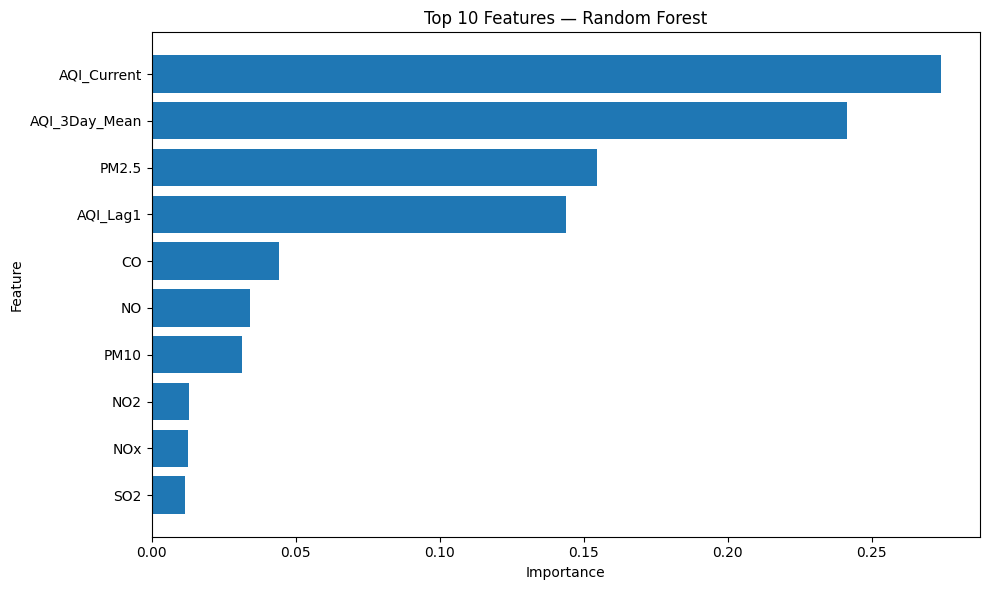

In [7]:
# ============================================================
# W7 CELL 7 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_importance = pd.DataFrame({
    "Feature": RF_FEATURES,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 50)
print(rf_importance.to_string(index=False))

# Plot top 10 features
top_n = 10

plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["Feature"].head(top_n)[::-1],
    rf_importance["Importance"].head(top_n)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features — Random Forest")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# W7 CELL 8 — FINAL W6 vs W7 COMPARISON
# ============================================================

# W6 final Decision Tree results
w6_accuracy = 0.9756
w6_precision = 0.8038
w6_recall = 0.8548
w6_f1 = 0.8285
w6_roc_auc = 0.9810

# W7 Random Forest results
w7_accuracy = rf_accuracy
w7_precision = rf_precision
w7_recall = rf_recall
w7_f1 = rf_f1
w7_roc_auc = rf_roc_auc

# Comparison table
model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [w6_accuracy, w7_accuracy],
    "Precision": [w6_precision, w7_precision],
    "Recall": [w6_recall, w7_recall],
    "F1": [w6_f1, w7_f1],
    "ROC_AUC": [w6_roc_auc, w7_roc_auc]
})

print("W6 vs W7 Model Comparison")
print("=" * 65)
print(model_comparison.to_string(index=False))

# Hazardous-day detection
print("\nHazardous-day detection:")
print("Decision Tree: 512 / 599 hazardous days detected")
print("Random Forest: 567 / 599 hazardous days detected")

print("\nMissed hazardous days:")
print("Decision Tree: 87")
print("Random Forest: 32")

W6 vs W7 Model Comparison
        Model  Accuracy  Precision   Recall       F1  ROC_AUC
Decision Tree  0.975600   0.803800 0.854800 0.828500 0.981000
Random Forest  0.971201   0.722293 0.946578 0.819364 0.992683

Hazardous-day detection:
Decision Tree: 512 / 599 hazardous days detected
Random Forest: 567 / 599 hazardous days detected

Missed hazardous days:
Decision Tree: 87
Random Forest: 32


In [11]:
# ============================================================
# W7 CELL 9 — RANDOM FOREST PARAMETER COMPARISON
# ============================================================

rf_configs = [
    {"max_depth": 8,  "min_samples_leaf": 5},
    {"max_depth": 12, "min_samples_leaf": 5},
    {"max_depth": 16, "min_samples_leaf": 5},
    {"max_depth": 12, "min_samples_leaf": 10},
    {"max_depth": 16, "min_samples_leaf": 10}
]

tuning_results = []

for config in rf_configs:

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=config["max_depth"],
        min_samples_split=10,
        min_samples_leaf=config["min_samples_leaf"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_rf_imputed,
        y_train_rf
    )

    pred = model.predict(X_test_rf_imputed)
    prob = model.predict_proba(X_test_rf_imputed)[:, 1]

    tuning_results.append({
        "Max_Depth": config["max_depth"],
        "Min_Leaf": config["min_samples_leaf"],
        "Accuracy": accuracy_score(y_test_rf, pred),
        "Precision": precision_score(
            y_test_rf, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test_rf, pred, zero_division=0
        ),
        "F1": f1_score(
            y_test_rf, pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test_rf, prob
        )
    })

rf_tuning_results = pd.DataFrame(tuning_results)

print("Random Forest Parameter Comparison")
print("=" * 80)
print(
    rf_tuning_results
    .sort_values("F1", ascending=False)
    .to_string(index=False)
)

Random Forest Parameter Comparison
 Max_Depth  Min_Leaf  Accuracy  Precision   Recall       F1  ROC_AUC
        16         5  0.972584   0.732903 0.948247 0.826783 0.992556
        12         5  0.971201   0.722293 0.946578 0.819364 0.992683
        16        10  0.969819   0.710362 0.949917 0.812857 0.992606
        12        10  0.969358   0.706320 0.951586 0.810811 0.992610
         8         5  0.969013   0.704208 0.949917 0.808813 0.992206


In [12]:
# ============================================================
# W7 CELL 10 — LEAKAGE-FREE RANDOM FOREST TUNING
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

# Use raw training features for CV
X_cv_rf = train_fe[RF_FEATURES].copy()
y_cv_rf = train_fe[TARGET].copy()

# Unique chronological dates
unique_dates_rf = np.sort(
    train_fe["Date"].unique()
)

tscv_rf = TimeSeriesSplit(n_splits=5)

rf_configs_cv = [
    {"max_depth": 8,  "min_samples_leaf": 5},
    {"max_depth": 12, "min_samples_leaf": 5},
    {"max_depth": 16, "min_samples_leaf": 5},
    {"max_depth": 12, "min_samples_leaf": 10},
    {"max_depth": 16, "min_samples_leaf": 10}
]

cv_results_rf = []

for config in rf_configs_cv:

    fold_f1 = []
    fold_recall = []

    for train_date_idx, val_date_idx in tscv_rf.split(unique_dates_rf):

        train_dates = unique_dates_rf[train_date_idx]
        val_dates = unique_dates_rf[val_date_idx]

        train_mask = train_fe["Date"].isin(train_dates)
        val_mask = train_fe["Date"].isin(val_dates)

        X_fold_train = X_cv_rf.loc[train_mask]
        X_fold_val = X_cv_rf.loc[val_mask]

        y_fold_train = y_cv_rf.loc[train_mask]
        y_fold_val = y_cv_rf.loc[val_mask]

        # Fit imputer ONLY on fold-training data
        fold_imputer = SimpleImputer(strategy="median")

        X_fold_train = fold_imputer.fit_transform(X_fold_train)
        X_fold_val = fold_imputer.transform(X_fold_val)

        # Random Forest
        model = RandomForestClassifier(
            n_estimators=150,
            max_depth=config["max_depth"],
            min_samples_split=10,
            min_samples_leaf=config["min_samples_leaf"],
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_fold_train, y_fold_train)

        pred = model.predict(X_fold_val)

        fold_f1.append(
            f1_score(y_fold_val, pred, zero_division=0)
        )

        fold_recall.append(
            recall_score(y_fold_val, pred, zero_division=0)
        )

    cv_results_rf.append({
        "Max_Depth": config["max_depth"],
        "Min_Leaf": config["min_samples_leaf"],
        "Mean_CV_F1": np.mean(fold_f1),
        "SE_F1": np.std(fold_f1, ddof=1) / np.sqrt(len(fold_f1)),
        "Mean_CV_Recall": np.mean(fold_recall)
    })

rf_cv_results = pd.DataFrame(cv_results_rf)

print("LEAKAGE-FREE RANDOM FOREST CV RESULTS")
print("=" * 80)

print(
    rf_cv_results
    .sort_values("Mean_CV_F1", ascending=False)
    .to_string(index=False)
)

LEAKAGE-FREE RANDOM FOREST CV RESULTS
 Max_Depth  Min_Leaf  Mean_CV_F1    SE_F1  Mean_CV_Recall
        16         5    0.849068 0.010718        0.918774
        12         5    0.848589 0.011416        0.918973
         8         5    0.847248 0.011283        0.924802
        12        10    0.844116 0.010519        0.931671
        16        10    0.841852 0.010664        0.929287


In [13]:
# ============================================================
# W7 CELL 11 — TRAIN FINAL RANDOM FOREST
# ============================================================

FINAL_MAX_DEPTH = 8
FINAL_MIN_LEAF = 5

final_random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=FINAL_MAX_DEPTH,
    min_samples_split=10,
    min_samples_leaf=FINAL_MIN_LEAF,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train on the complete training set
final_random_forest.fit(
    X_train_rf_imputed,
    y_train_rf
)

print("Final Random Forest trained successfully.")

print("\nFinal parameters:")
print("Number of trees:", final_random_forest.n_estimators)
print("Maximum depth:", final_random_forest.max_depth)
print("Minimum samples split:", final_random_forest.min_samples_split)
print("Minimum samples leaf:", final_random_forest.min_samples_leaf)
print("Class weight:", final_random_forest.class_weight)

Final Random Forest trained successfully.

Final parameters:
Number of trees: 300
Maximum depth: 8
Minimum samples split: 10
Minimum samples leaf: 5
Class weight: balanced


In [14]:
# ============================================================
# W7 CELL 12 — FINAL RANDOM FOREST TEST EVALUATION
# ============================================================

# Final predictions
y_pred_rf_final = final_random_forest.predict(
    X_test_rf_imputed
)

y_prob_rf_final = final_random_forest.predict_proba(
    X_test_rf_imputed
)[:, 1]

# Final metrics
final_rf_accuracy = accuracy_score(
    y_test_rf, y_pred_rf_final
)

final_rf_precision = precision_score(
    y_test_rf, y_pred_rf_final, zero_division=0
)

final_rf_recall = recall_score(
    y_test_rf, y_pred_rf_final, zero_division=0
)

final_rf_f1 = f1_score(
    y_test_rf, y_pred_rf_final, zero_division=0
)

final_rf_roc_auc = roc_auc_score(
    y_test_rf, y_prob_rf_final
)

print("FINAL RANDOM FOREST — TEST RESULTS")
print("=" * 50)
print(f"Accuracy : {final_rf_accuracy:.4f}")
print(f"Precision: {final_rf_precision:.4f}")
print(f"Recall   : {final_rf_recall:.4f}")
print(f"F1 Score : {final_rf_f1:.4f}")
print(f"ROC-AUC  : {final_rf_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_rf,
    y_pred_rf_final
))

print("\nClassification Report:")
print(classification_report(
    y_test_rf,
    y_pred_rf_final,
    target_names=["Non-hazardous", "Hazardous"],
    zero_division=0
))

FINAL RANDOM FOREST — TEST RESULTS
Accuracy : 0.9690
Precision: 0.7042
Recall   : 0.9499
F1 Score : 0.8088
ROC-AUC  : 0.9922

Confusion Matrix:
[[7843  239]
 [  30  569]]

Classification Report:
               precision    recall  f1-score   support

Non-hazardous       1.00      0.97      0.98      8082
    Hazardous       0.70      0.95      0.81       599

     accuracy                           0.97      8681
    macro avg       0.85      0.96      0.90      8681
 weighted avg       0.98      0.97      0.97      8681



FINAL RANDOM FOREST FEATURE IMPORTANCE
      Feature  Importance
  AQI_Current    0.284009
AQI_3Day_Mean    0.253251
        PM2.5    0.153806
     AQI_Lag1    0.146102
           CO    0.044116
           NO    0.032601
         PM10    0.029429
          NOx    0.010294
          NO2    0.010113
          SO2    0.009443
          NH3    0.006513
      Toluene    0.006429
      Benzene    0.003858
           O3    0.003339
       Xylene    0.002789
        Month    0.002391
    DayOfWeek    0.001518


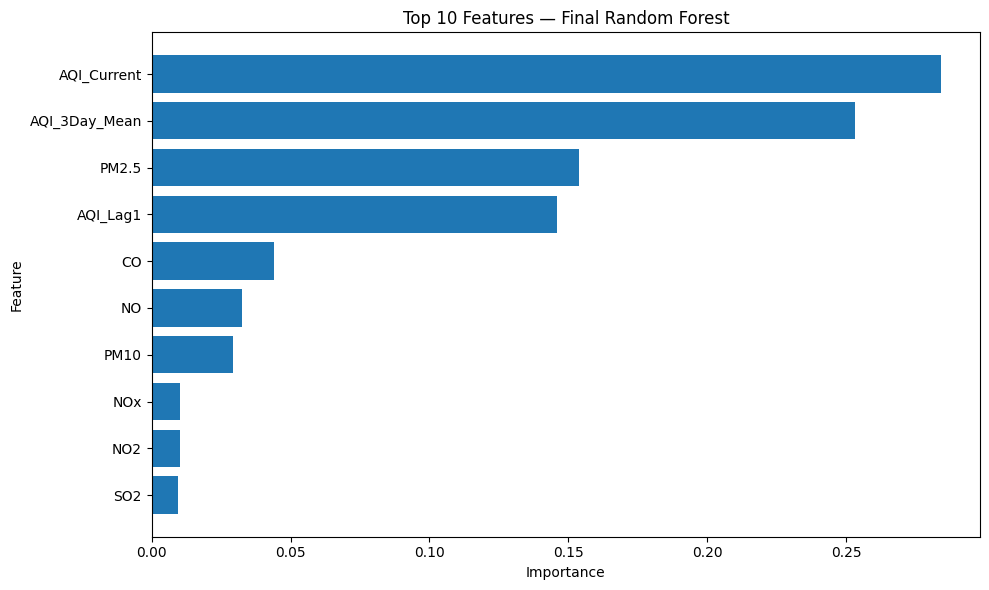

In [15]:
# ============================================================
# W7 CELL 13 — FINAL RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

final_rf_importance = pd.DataFrame({
    "Feature": RF_FEATURES,
    "Importance": final_random_forest.feature_importances_
})

final_rf_importance = final_rf_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("FINAL RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 55)
print(final_rf_importance.to_string(index=False))

# Plot top 10 features
top_n = 10

plt.figure(figsize=(10, 6))

plt.barh(
    final_rf_importance["Feature"].head(top_n)[::-1],
    final_rf_importance["Importance"].head(top_n)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features — Final Random Forest")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# W7 CELL 14 — SAVE FINAL RANDOM FOREST RESULTS
# ============================================================

import os

os.makedirs("../data", exist_ok=True)

# 1. Save final model results
w7_final_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [final_rf_accuracy],
    "Precision": [final_rf_precision],
    "Recall": [final_rf_recall],
    "F1": [final_rf_f1],
    "ROC_AUC": [final_rf_roc_auc],
    "N_Estimators": [final_random_forest.n_estimators],
    "Max_Depth": [final_random_forest.max_depth],
    "Min_Samples_Split": [final_random_forest.min_samples_split],
    "Min_Samples_Leaf": [final_random_forest.min_samples_leaf]
})

w7_final_results.to_csv(
    "../data/w7_random_forest_results.csv",
    index=False
)

# 2. Save feature importance table
final_rf_importance.to_csv(
    "../data/w7_random_forest_feature_importance.csv",
    index=False
)

# 3. Save feature-importance plot
plt.figure(figsize=(10, 6))

plt.barh(
    final_rf_importance["Feature"].head(10)[::-1],
    final_rf_importance["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features — Final Random Forest")
plt.tight_layout()

plt.savefig(
    "../data/w7_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("W7 final results saved successfully.")

print("\nFinal W7 Results:")
print(w7_final_results.to_string(index=False))

print("\nFiles saved:")
print("1. w7_random_forest_results.csv")
print("2. w7_random_forest_feature_importance.csv")
print("3. w7_random_forest_feature_importance.png")

W7 final results saved successfully.

Final W7 Results:
        Model  Accuracy  Precision   Recall       F1  ROC_AUC  N_Estimators  Max_Depth  Min_Samples_Split  Min_Samples_Leaf
Random Forest  0.969013   0.704208 0.949917 0.808813 0.992206           300          8                 10                 5

Files saved:
1. w7_random_forest_results.csv
2. w7_random_forest_feature_importance.csv
3. w7_random_forest_feature_importance.png
